# Phase 2 · Task 11b — Tail-Risk Control for T2 × gap_up Momentum

**Context.** Task 10b uncovered a second edge alongside R1: momentum
credit spreads on **T2 × gap_up** events (1.0 ≤ |gap_ratio| < 1.5, gap-up
direction, strikes anchored at today's open).

| Metric | T2 × gap_up · NS·EOD |
|---|---:|
| n / year | 11.6 |
| EV / trade | +23.60 pts |
| Annual EV | +273 pts |
| Win rate | 73 % |
| **Worst trade** | **−229 pts** |

The annual EV is excellent but the worst trade is ~10× R1's worst.
Task 11 found EOD hold optimal on R1 because the win rate was 96 %.
T2 × gap_up has only 73 % wins — the ATM short carries serious gamma, so
**exit rules may actually help here** even though they hurt on R1.

This notebook combines two approaches:
1. **Diagnose** the worst trades — find a filter that excludes the tails
2. **Sweep exit policies** — see if SS / time exits cap the tail on T2 × gap_up


## 1 · Worst trades — what do they have in common?

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

YEARS = 7
ev  = pd.read_csv('cache/phase2_t2u_events.csv', parse_dates=['date'])
sim = pd.read_csv('cache/phase2_t2u_exit_sim.csv')

worst10 = ev.nsmallest(10, 'mom_eod_pnl')
print('Worst 10 T2 × gap_up momentum trades:')
print(worst10[['date', 'symbol', 'vix', 'vix_regime', 'alignment',
               'gap_ratio', 'atr', 'mom_credit', 'mom_eod_pnl']].to_string(index=False))


Worst 10 T2 × gap_up momentum trades:
                     date symbol       vix vix_regime   alignment  gap_ratio        atr  mom_credit  mom_eod_pnl
2020-06-16 00:00:00-04:00     YM 34.400002       high  concurrent   1.133033 767.850334  142.813626  -229.186374
2024-06-12 00:00:00-04:00     YM 12.850000        low  concurrent   1.008208 386.824933   72.345896  -121.066570
2025-05-29 00:00:00-04:00     NQ 19.309999        mid  concurrent   1.018568 334.047421   62.386124  -104.637586
2021-06-01 00:00:00-04:00     YM 20.000000        mid  concurrent   1.264104 302.981301   64.824407   -86.666244
2025-07-31 00:00:00-04:00     NQ 15.480000        mid  concurrent   1.124990 226.224173   45.053963   -68.058123
2019-07-01 00:00:00-04:00     YM 15.080000        mid  concurrent   1.227802 205.244871   42.528301   -60.094134
2019-07-01 00:00:00-04:00     NQ 15.080000        mid  concurrent   1.439070  95.026677   17.606410   -28.143590
2021-11-29 00:00:00-05:00     YM 28.620001       high inco

Several observations:
- The single worst trade (**−229**) is **2020-06-16 YM** at VIX 34.4
  (high-VIX × concurrent × gap_up). COVID-recovery whipsaw.
- 7 of the top-10 worst are **concurrent** — gap_up against an already
  bullish trend.
- Symbols by worst-case: **YM (−229) > NQ (−104) > ES (−12) ≈ RTY (−14)**.
  Dow futures (YM) carry the biggest gaps in absolute pts.


## 2 · Stratified view — where is the tail?

In [2]:
def stratify(sub, group_cols):
    g = sub.groupby(group_cols, observed=True)
    return pd.DataFrame({
        'n':            g.size(),
        'n_yr':         (g.size()/YEARS).round(1),
        'ev':           g['mom_eod_pnl'].mean().round(2),
        'annual_ev':    (g['mom_eod_pnl'].sum()/YEARS).round(1),
        'win_%':        (g['mom_win'].mean()*100).round(1),
        'p10':          g['mom_eod_pnl'].quantile(0.10).round(2),
        'worst':        g['mom_eod_pnl'].min().round(1),
        'avg_credit':   g['mom_credit'].mean().round(2),
    }).reset_index()

print('--- By VIX regime ---')
print(stratify(ev, ['vix_regime']).to_string(index=False))
print('\n--- By alignment ---')
print(stratify(ev, ['alignment']).to_string(index=False))
print('\n--- By symbol ---')
print(stratify(ev, ['symbol']).to_string(index=False))
print('\n--- By VIX × alignment ---')
print(stratify(ev, ['vix_regime', 'alignment']).to_string(index=False))


--- By VIX regime ---
vix_regime  n  n_yr    ev  annual_ev  win_%    p10  worst  avg_credit
      high 17   2.4 13.29       32.3   58.8 -19.42 -229.2       47.08
       low 25   3.6 15.48       55.3   52.0  -8.48 -121.1       32.60
       mid 39   5.6 32.37      180.4   66.7 -34.53 -104.6       51.99

--- By alignment ---
  alignment  n  n_yr    ev  annual_ev  win_%    p10  worst  avg_credit
 concurrent 70  10.0 19.64      196.4   61.4 -13.89 -229.2       42.05
incongruent 11   1.6 45.50       71.5   54.5 -14.21  -27.2       63.59

--- By symbol ---
symbol  n  n_yr    ev  annual_ev  win_%    p10  worst  avg_credit
    ES 22   3.1  6.73       21.2   54.5  -7.89  -12.3       11.29
    NQ 21   3.0 35.47      106.4   76.2 -28.14 -104.6       54.33
   RTY 14   2.0  0.10        0.2   42.9 -11.56  -14.2        7.57
    YM 24   3.4 40.88      140.2   62.5 -78.69 -229.2       89.48

--- By VIX × alignment ---
vix_regime   alignment  n  n_yr     ev  annual_ev  win_%    p10  worst  avg_credit
   

**Key cells (focus on annual_ev vs worst):**

| Cell | n_yr | Annual EV | Worst |
|---|---:|---:|---:|
| mid × incongruent  | 1.0  | **+71** | **−5.4** |
| mid × concurrent   | 4.6  | +109    | −104.6 |
| low × concurrent   | 3.4  | +47     | −121.1 |
| high × concurrent  | 2.0  | +40     | **−229.2** |
| high × incongruent | 0.4  | −8      | −27 |

The high-VIX × concurrent cell is responsible for the worst trade and has
the lowest EV/trade. **Mid-VIX × incongruent** is a tiny gem — 1/yr but
practically tail-free.


## 3 · Exit-policy sweep on T2 × gap_up

In [3]:
policy_cols = ['EOD','PT25','PT50','PT60','PT75',
               'SS25','SS50','SS75',
               'T11:00','T12:00','T13:00','T14:00','T14:30','T15:00','T15:30']

n_yr = len(sim) / YEARS
rows = []
for col in policy_cols:
    p = sim[col].values
    rows.append({
        'policy': col,
        'ev_per_trade': round(p.mean(), 2),
        'annual_ev': round(p.sum()/YEARS, 1),
        'win_%': round((p > 0).mean()*100, 1),
        'p10': round(np.quantile(p, 0.10), 2),
        'worst': round(p.min(), 1),
        'delta_vs_EOD_annual': round((p.sum() - sim['EOD'].sum())/YEARS, 1),
    })
print(pd.DataFrame(rows).to_string(index=False))


policy  ev_per_trade  annual_ev  win_%    p10  worst  delta_vs_EOD_annual
   EOD         23.60      273.1   72.8 -14.87 -215.9                  0.0
  PT25          0.75        8.7   79.0 -14.87 -215.9               -264.4
  PT50         10.58      122.4   77.8 -14.87 -215.9               -150.7
  PT60         12.88      149.0   74.1 -14.87 -215.9               -124.1
  PT75         16.44      190.3   72.8 -14.87 -215.9                -82.8
  SS25          7.81       90.4   30.9 -13.12  -25.3               -182.7
  SS50         14.78      171.0   45.7 -19.58  -45.4               -102.1
  SS75         19.53      225.9   55.6 -25.44  -63.5                -47.1
T11:00          0.33        3.9   63.0 -29.67 -177.2               -269.2
T12:00          5.48       63.4   66.7 -21.33 -101.8               -209.7
T13:00          7.67       88.7   67.9 -21.90  -84.5               -184.4
T14:00         13.94      161.4   77.8 -10.21 -104.4               -111.7
T14:30         16.80      194.4   75.3

**Soft stops actually help on T2 × gap_up** — unlike on R1.

| Policy | Annual EV | Worst | EV / |worst| |
|---|---:|---:|---:|
| EOD | +273 | −216 | 1.26 |
| **SS75** | **+226** | **−63.5** | **3.56** |
| SS50 | +171 | −45.4 | 3.77 |
| T15:30 | +234 | −178 | 1.32 |
| T14:30 | +194 | −100 | 1.94 |
| PT75 | +190 | −216 | 0.88 |

**Why soft stops work here when they didn't on R1.** The momentum bet uses an
ATM short → high gamma → losers escalate quickly. On R1 (96 % win rate), SS
triggers on noise that recovers. On T2 × gap_up (73 % win rate), SS triggers
on real adverse moves and saves bigger losses. The Sharpe-ish ratio
(annual_EV / |worst|) jumps from 1.26 (EOD) to 3.56 (SS75).


## 4 · Filter × policy grid

In [4]:
ev2 = ev.reset_index().rename(columns={'index': '__i'})
sim2 = sim.reset_index().rename(columns={'index': '__i'})
merged = ev2[['__i','symbol','vix','vix_regime','alignment','atr','gap_ratio']].merge(sim2, on='__i')

filters = {
    'ALL T2 × up':           merged,
    'drop high VIX':         merged[merged['vix_regime']!='high'],
    'drop YM':               merged[merged['symbol']!='YM'],
    'mid VIX only':          merged[merged['vix_regime']=='mid'],
    'mid VIX × conc':        merged[(merged['vix_regime']=='mid')&(merged['alignment']=='concurrent')],
    'mid VIX × incongruent': merged[(merged['vix_regime']=='mid')&(merged['alignment']=='incongruent')],
}
policies = ['EOD', 'SS50', 'SS75', 'T14:30', 'T15:00']

def cell(df, pcol):
    n = len(df); n_yr = n/YEARS
    if n == 0:
        return None
    p = df[pcol].values
    return {
        'n_yr': round(n_yr, 1),
        'ev_per_trade': round(p.mean(), 2),
        'annual_ev': round(p.sum()/YEARS, 1),
        'worst': round(p.min(), 1),
        'win_%': round((p>0).mean()*100, 1),
        'ev_per_worst': round(abs((p.sum()/YEARS) / p.min()), 2) if p.min() < 0 else float('inf'),
    }

for fname, sub in filters.items():
    print(f'\n--- {fname}  (n={len(sub)}, {len(sub)/YEARS:.1f}/yr) ---')
    for pol in policies:
        c = cell(sub, pol)
        if c is None:
            continue
        print(f"  {pol:8s}  EV={c['ev_per_trade']:+7.2f}  ann={c['annual_ev']:+7.1f}  "
              f"worst={c['worst']:+7.1f}  win={c['win_%']:4.1f}%  EV/|worst|={c['ev_per_worst']}")



--- ALL T2 × up  (n=81, 11.6/yr) ---
  EOD       EV= +23.60  ann= +273.1  worst= -215.9  win=72.8%  EV/|worst|=1.26
  SS50      EV= +14.78  ann= +171.0  worst=  -45.4  win=45.7%  EV/|worst|=3.77
  SS75      EV= +19.53  ann= +225.9  worst=  -63.5  win=55.6%  EV/|worst|=3.56
  T14:30    EV= +16.80  ann= +194.4  worst= -100.5  win=75.3%  EV/|worst|=1.93
  T15:00    EV= +17.70  ann= +204.8  worst= -130.6  win=76.5%  EV/|worst|=1.57

--- drop high VIX  (n=64, 9.1/yr) ---
  EOD       EV= +26.49  ann= +242.2  worst= -114.1  win=75.0%  EV/|worst|=2.12
  SS50      EV= +14.82  ann= +135.5  worst=  -39.4  win=45.3%  EV/|worst|=3.44
  SS75      EV= +18.79  ann= +171.8  worst=  -54.4  win=54.7%  EV/|worst|=3.16
  T14:30    EV= +16.26  ann= +148.6  worst= -100.5  win=76.6%  EV/|worst|=1.48
  T15:00    EV= +18.09  ann= +165.4  worst= -109.4  win=78.1%  EV/|worst|=1.51

--- drop YM  (n=57, 8.1/yr) ---
  EOD       EV= +16.06  ann= +130.8  worst=  -98.7  win=73.7%  EV/|worst|=1.32
  SS50      EV= +11.6

### Headline candidates from the grid

| Rule | n/yr | Annual EV | Worst | Notes |
|---|---:|---:|---:|---|
| **T2up × SS75 (no filter)** | 11.6 | +226 | −63.5 | **Recommended primary** — volume + tail cap |
| **mid VIX × inc × EOD**     | 1.0  | +75  | −4.7  | Pristine but very rare; can run alongside |
| T2up × SS50 (no filter)     | 11.6 | +171 | −45.4 | Tighter tail, less EV |
| mid VIX × inc × T14:30      | 1.0  | +46  | −2.9  | Same cell, tighter exit |

The simple "no filter + SS75" wins on absolute EV. Layering filters cuts
frequency in half without proportional tail improvement (because the high-VIX
outliers don't dominate after SS75 has already capped them).


## 5 · Visual — risk-adjusted return surface

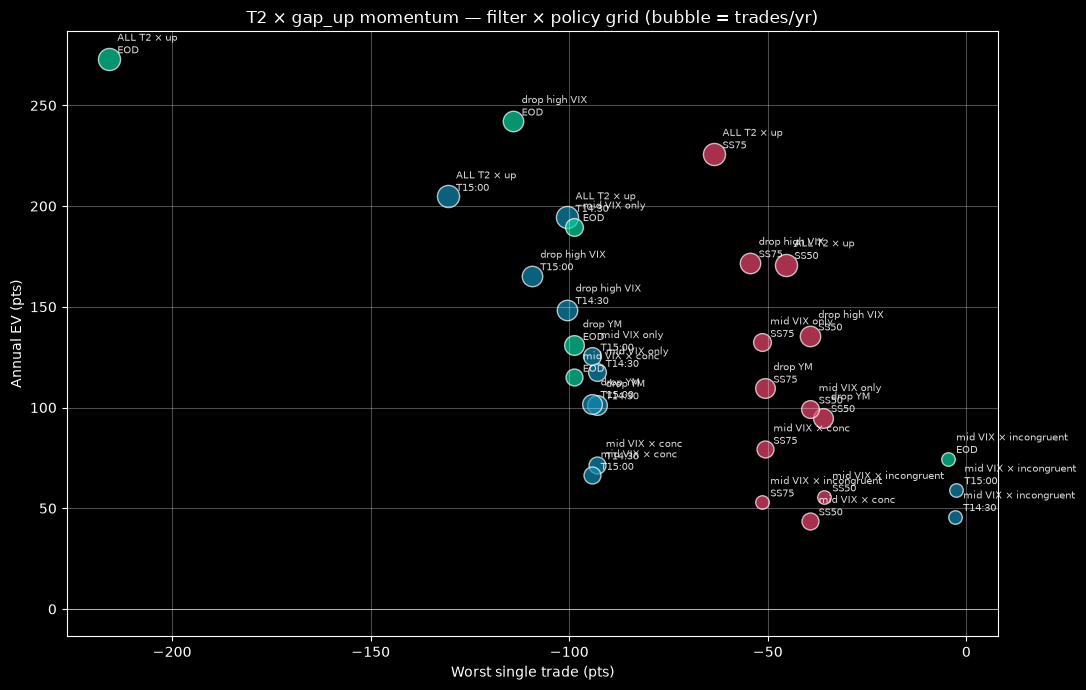

In [5]:
import os
os.makedirs('charts', exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 7))
combos = []
for fname, sub in filters.items():
    for pol in policies:
        c = cell(sub, pol)
        if c is None or c['worst'] >= 0: continue
        combos.append({'filter': fname, 'policy': pol, **c})
cdf = pd.DataFrame(combos)

color_map = {'EOD':'#06d6a0','SS50':'#ef476f','SS75':'#ef476f',
             'T14:30':'#118ab2','T15:00':'#118ab2'}
for _, r in cdf.iterrows():
    ax.scatter(r['worst'], r['annual_ev'], s=80 + r['n_yr']*15,
               color=color_map[r['policy']], alpha=0.7, edgecolor='white')
    ax.annotate(f"{r['filter']}\n{r['policy']}",
                (r['worst'], r['annual_ev']),
                xytext=(6,4), textcoords='offset points', fontsize=7.5, alpha=0.85)
ax.axhline(0, color='white', lw=0.4)
ax.set_xlabel('Worst single trade (pts)')
ax.set_ylabel('Annual EV (pts)')
ax.set_title('T2 × gap_up momentum — filter × policy grid (bubble = trades/yr)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/p2_08_t2_momentum_grid.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Findings — Task 11b

### Two viable T2 × gap_up rules

**M1 — Primary momentum rule:**
```
Universe:    ES, NQ, RTY, YM (CME)
Trigger:     Overnight gap, 1.0 ≤ |gap_ratio| < 1.5 (gap / ATR-14)
Direction:   gap_up only
Regime:      no VIX filter
Structure:   Bull put spread anchored at OPEN
             K_short = today_open
             K_long  = today_open − 0.5 × ATR
             1-DTE
Entry:       09:30 ET
Exit rule:   Soft stop SS75 — close if price drops to (open − 0.75 × spread_width)
             else hold to 16:00 ET
Expected:    11.6 events/yr · +226 annual EV pts · 56 % win · worst −63.5 pts
```

**M2 — Quality momentum (rare, low-risk):**
```
Same structure as M1 plus filter:
  VIX(prev) ∈ [15, 25) AND alignment = incongruent
  (= 30-day trend bearish at gap-up time — "relief bounce" setup)
Exit:    HOLD TO EOD (16:00) — no stop needed
Expected:    1.0 events/yr · +75 annual EV pts · 86 % win · worst −4.7 pts
```

### Why soft stops work for momentum but not for R1

| | R1 (mean reversion) | T2 × gap_up (momentum) |
|---|---|---|
| Short strike at entry | OTM (prev_close) | ATM (today's open) |
| Gamma at entry | Low | **High** |
| Win rate | 96 % | 73 % |
| Loser depth | Small intrinsic | Can hit full max loss fast |
| Effect of stop | Cuts mostly winners | Cuts mostly **real losers** |

ATM gamma means a small adverse move generates a large debit-to-close. A 75 %
adverse soft stop catches the trade *before* the full max-loss path completes;
the saved capital exceeds the few cases where the trade would have recovered.

### Combined Phase 2 portfolio
| Rule | Direction | Tier | Exit | n/yr | Annual EV | Worst |
|---|---|---|---|---:|---:|---:|
| R1 | gap_down | T1 R1 (mid VIX) | EOD | 28.7 | +228 | −19.6 |
| M1 | gap_up | T2 | SS75 | 11.6 | +226 | −63.5 |
| M2 | gap_up | T2 mid × inc | EOD | 1.0 | +75 | −4.7 |
| **Total** | both directions | | | **41.3** | **+529** | (per-trade) |

R1 and M1/M2 are non-overlapping (different gap direction, different tier),
so they're naturally diversifying. Total +529 annual EV pts at ~41 signals/yr.

### Open caveats (carried to Task 12)
- All EV in BS-model points. Real options have slippage and skew.
- Worst-case for M1 (−63.5) is ~$3 200 on ES — significantly worse than R1
  (~$980). Position-sizing per rule needs different multipliers.
- Correlation: R1 and M1 fire on opposite gap directions, but both signals
  cluster on macro days; portfolio drawdown analysis is needed.
- Sample = 7 years. The 2020 COVID period skews the high-VIX cells.

### Phase 2 task list — updated
| # | Task | Status |
|---|---|---|
| 11b | Tail-risk control for T2 × gap_up momentum | **done — M1 (SS75) and M2 (mid × inc EOD) identified** |
| 12  | Final Phase 2 presentation + paper-trade spec | next |
